<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Data Preparation and Exploration

### 1. Data Loading

In [7]:
import pandas as pd

# Load the dataset and parse the 'date' column, then set it as the index
df = pd.read_csv('/content/exchange_rate.csv', parse_dates=['date'], index_col='date')

# Infer and set the frequency of the datetime index
# This helps statsmodels correctly handle time series operations like forecasting
df.index.freq = pd.infer_freq(df.index)

# Display the first 5 rows and info to verify data loading and date parsing
print("First 5 rows of the dataset after parsing date and setting index:")
display(df.head())
print("\nDataFrame Info after parsing date:")
df.info()
print("\nCheck for duplicate dates:")
print(f"Number of duplicate dates: {df.index.duplicated().sum()}")

First 5 rows of the dataset after parsing date and setting index:


,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849



DataFrame Info after parsing date:
<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB

Check for duplicate dates:
Number of duplicate dates: 0


### 2. Initial Exploration: Plotting the Time Series

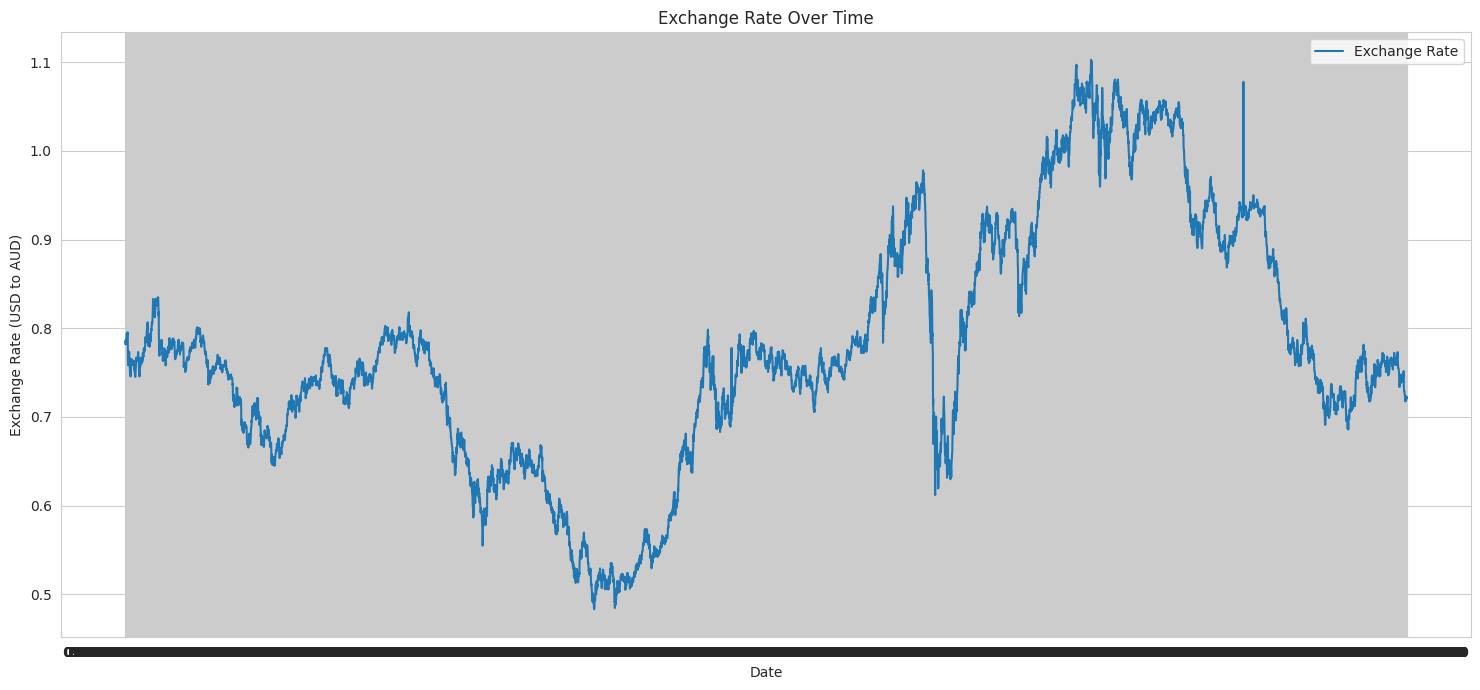

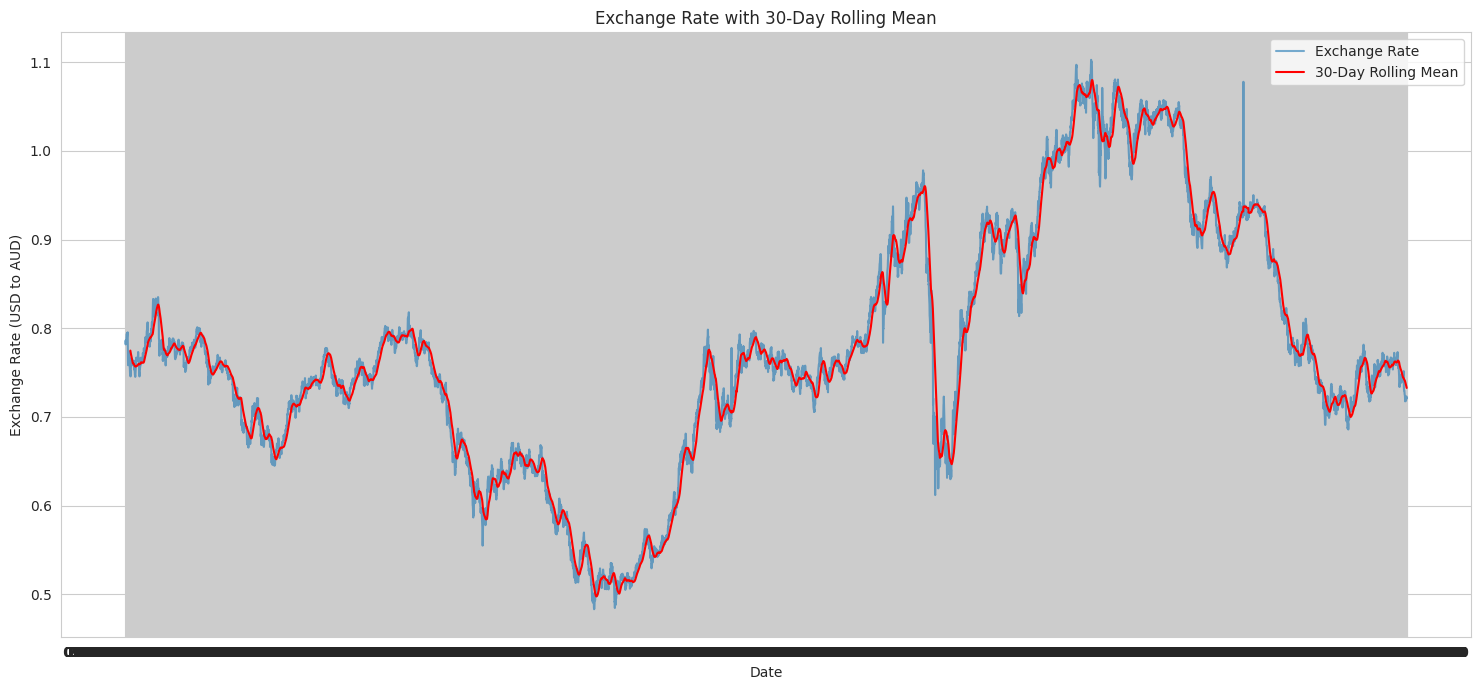

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Plot the time series of the exchange rate
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Ex_rate'], label='Exchange Rate')
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (USD to AUD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting a rolling mean to highlight trend (e.g., 30-day rolling mean)
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Ex_rate'], label='Exchange Rate', alpha=0.6)
plt.plot(df.index, df['Ex_rate'].rolling(window=30).mean(), label='30-Day Rolling Mean', color='red')
plt.title('Exchange Rate with 30-Day Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (USD to AUD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Part 2: Model Building - ARIMA

### 1. Parameter Selection for ARIMA (ACF and PACF plots)

ADF Test for Original Series:
ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477
Critical Values:
	1%: -3.4312123140180137
	5%: -2.861921078147796
	10%: -2.5669728434336108
Fail to reject the null hypothesis (H0), the series is non-stationary.

ADF Test for Differenced Series:
ADF Statistic: -99.39343120118632
p-value: 0.0
Critical Values:
	1%: -3.4312123140180137
	5%: -2.861921078147796
	10%: -2.5669728434336108
Reject the null hypothesis (H0), the series is stationary.


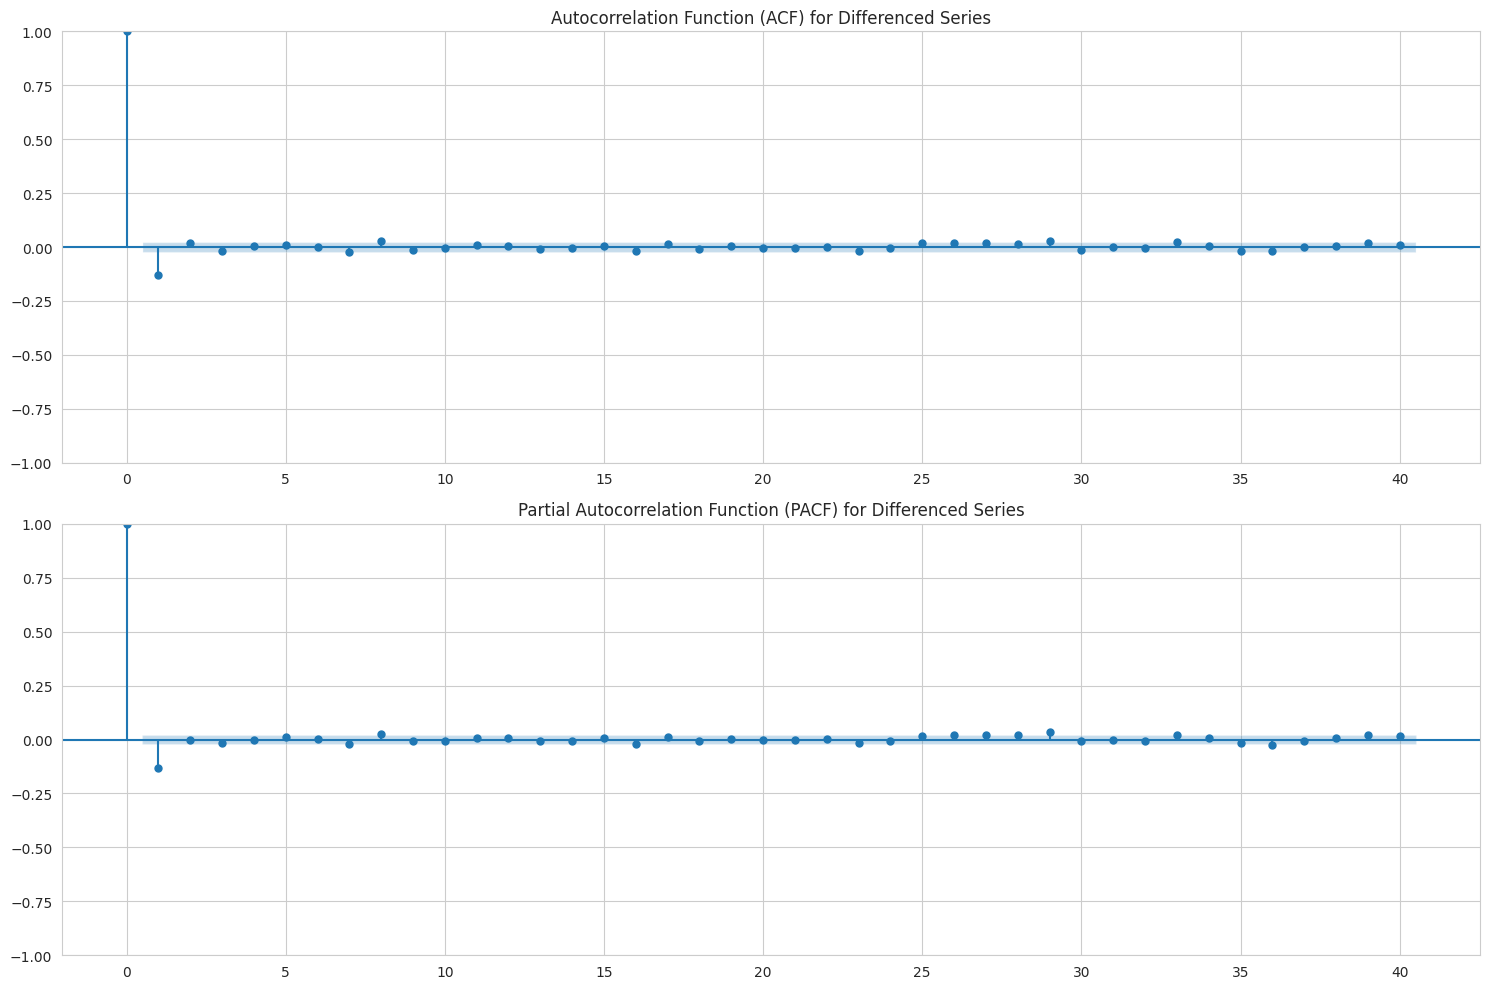

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Before plotting ACF/PACF, it's often useful to check for stationarity
# A simple way to assess this is to look at the Augmented Dickey-Fuller (ADF) test
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    if result[1] <= 0.05:
        print("Reject the null hypothesis (H0), the series is stationary.")
    else:
        print("Fail to reject the null hypothesis (H0), the series is non-stationary.")

print("ADF Test for Original Series:")
adf_test(df['Ex_rate'])

# If non-stationary, difference the series
# The 'd' parameter in ARIMA refers to the number of differencing steps needed to make a time series stationary.
# Let's apply first-order differencing and re-run the ADF test.
df_diff = df['Ex_rate'].diff().dropna()
print("\nADF Test for Differenced Series:")
adf_test(df_diff)

# Plot ACF and PACF for the (possibly differenced) series
plt.figure(figsize=(15, 10))
plt.subplot(211)
plot_acf(df_diff, ax=plt.gca(), lags=40)
plt.title('Autocorrelation Function (ACF) for Differenced Series')
plt.subplot(212)
plot_pacf(df_diff, ax=plt.gca(), lags=40)
plt.title('Partial Autocorrelation Function (PACF) for Differenced Series')
plt.tight_layout()
plt.show()

### 2. Model Fitting

In [6]:
from statsmodels.tsa.arima.model import ARIMA

# Split data into training and testing sets
train_size = int(len(df) * 0.8)
train_data, test_data = df[0:train_size], df[train_size:]

print(f"Training data points: {len(train_data)}")
print(f"Test data points: {len(test_data)}")

# Fit ARIMA model
# Based on ACF/PACF, we will start with (1,1,1)
# The 'order' parameter is (p, d, q)
model = ARIMA(train_data['Ex_rate'], order=(1,1,1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

Training data points: 6070
Test data points: 1518


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 15 Apr 2026   AIC                         -45432.092
Time:                        11:16:08   BIC                         -45411.959
Sample:                             0   HQIC                        -45425.104
                               - 6070                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

### 3. Diagnostics: Analyze the Residuals

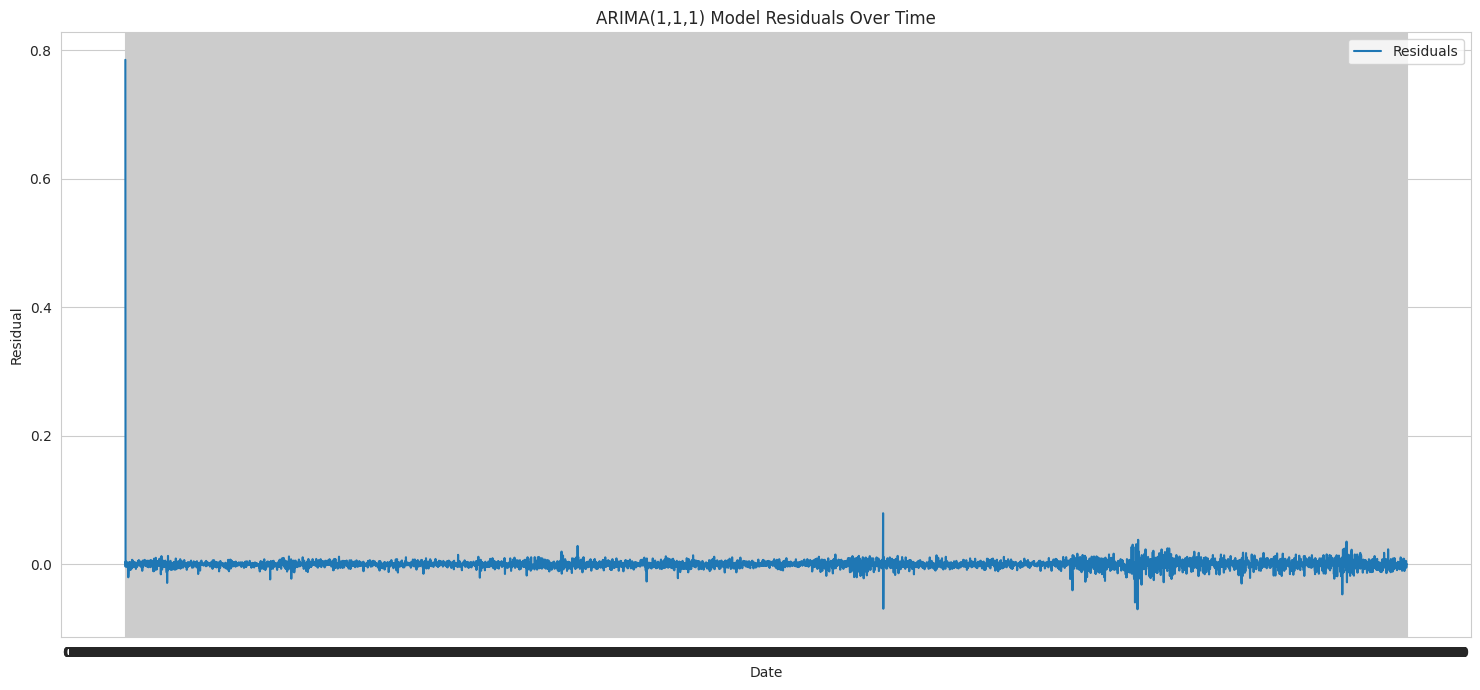

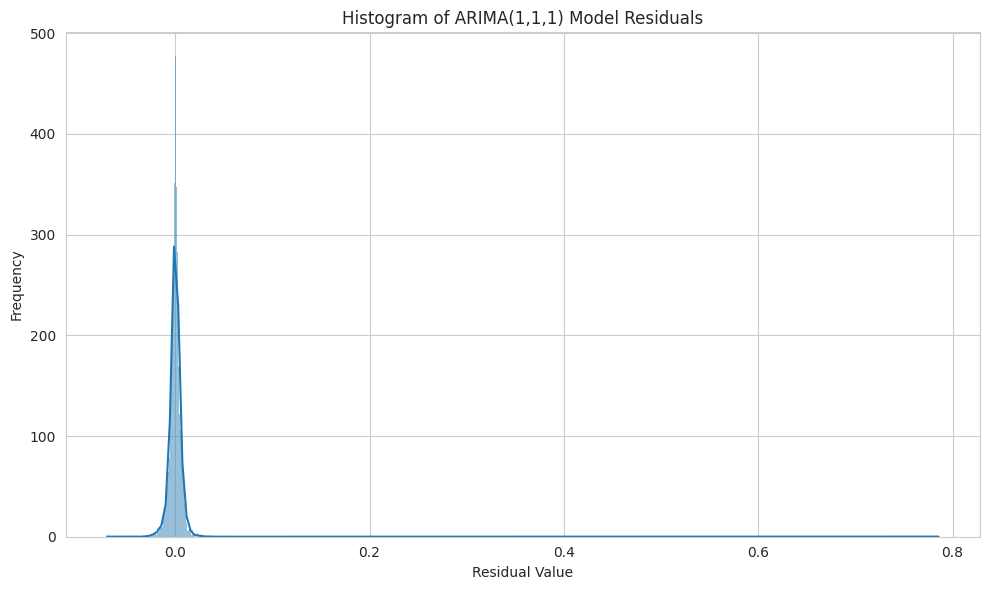

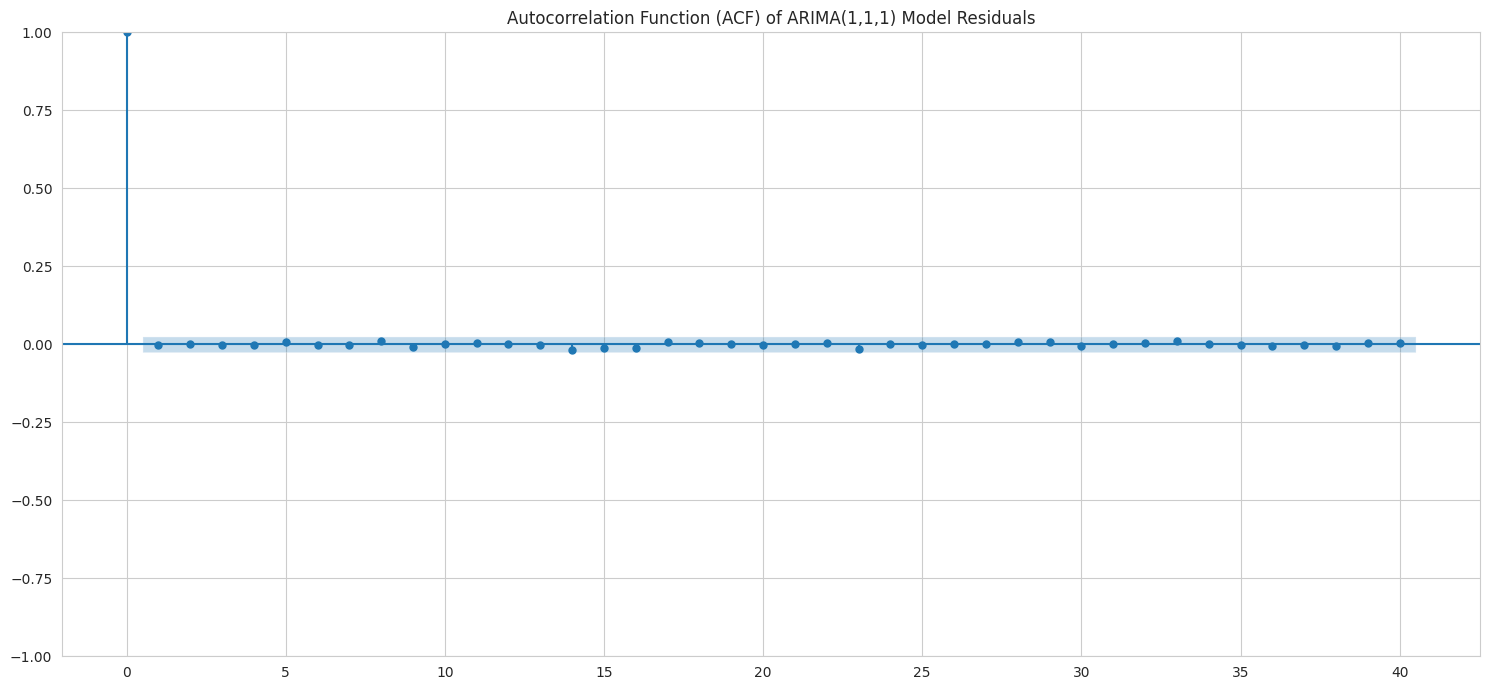

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# Get the residuals from the fitted model
residuals = model_fit.resid

# Plot residuals over time
plt.figure(figsize=(15, 7))
plt.plot(residuals.index, residuals, label='Residuals')
plt.title('ARIMA(1,1,1) Model Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot histogram of residuals to check for normality
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of ARIMA(1,1,1) Model Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot ACF of residuals to check for any remaining autocorrelation
plt.figure(figsize=(15, 7))
plot_acf(residuals, ax=plt.gca(), lags=40)
plt.title('Autocorrelation Function (ACF) of ARIMA(1,1,1) Model Residuals')
plt.tight_layout()
plt.show()

### 4. Forecasting

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


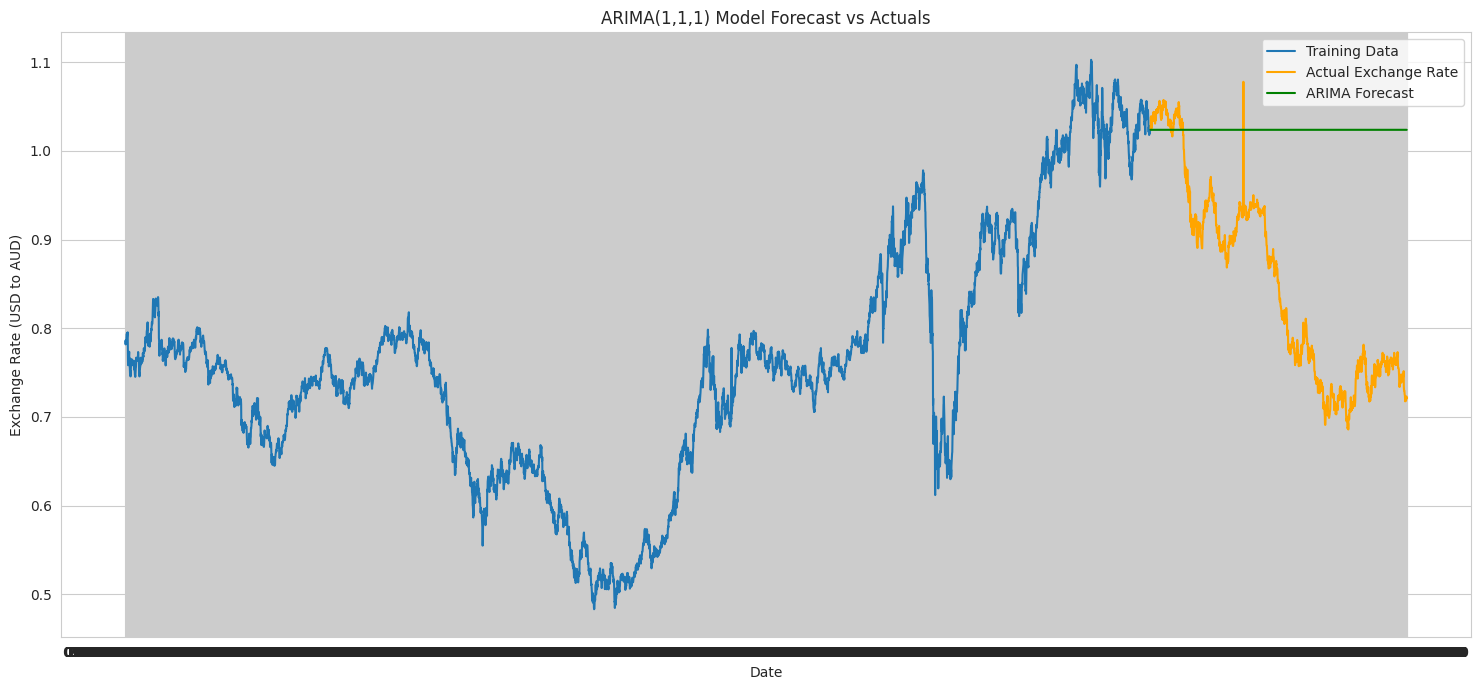

In [9]:
# Perform out-of-sample forecasting
# The 'start' and 'end' parameters define the forecast period relative to the training data
forecast_steps = len(test_data)
forecast = model_fit.predict(start=len(train_data), end=len(df)-1, typ='levels')

# Ensure forecast index matches test_data index for plotting and evaluation
forecast.index = test_data.index

# Plot the forecasts against actual values
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['Ex_rate'], label='Training Data')
plt.plot(test_data.index, test_data['Ex_rate'], label='Actual Exchange Rate', color='orange')
plt.plot(forecast.index, forecast, label='ARIMA Forecast', color='green')
plt.title('ARIMA(1,1,1) Model Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (USD to AUD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Part 3: Model Evaluation and Comparison

### 1. Evaluation Metrics for ARIMA

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(test_data['Ex_rate'], forecast)
rmse = np.sqrt(mean_squared_error(test_data['Ex_rate'], forecast))

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(test_data['Ex_rate'], forecast)

print(f'ARIMA Model MAE: {mae:.4f}')
print(f'ARIMA Model RMSE: {rmse:.4f}')
print(f'ARIMA Model MAPE: {mape:.2f}%')


ARIMA Model MAE: 0.1777
ARIMA Model RMSE: 0.2054
ARIMA Model MAPE: 22.80%


### 2. Exponential Smoothing Model

#### a. Model Fitting

In [11]:
from statsmodels.tsa.api import ExponentialSmoothing

# Fit an Exponential Smoothing model
# We'll start with a basic Additive trend and Additive seasonality (daily data, so seasonality of 7 if weekly pattern expected)
# Given the daily frequency and lack of clear seasonality in initial plots, a simple model without strong seasonality might be appropriate initially.
# However, let's try with additive trend and no seasonality first, or a small period if justified.
# Let's consider a simple model without seasonality initially, just trend.

# Given the inferred frequency is daily, and no strong daily seasonality was observed,
# we can start with a Holt's Linear Trend method or a simple ETS without a seasonal component.
# Let's try an additive trend ('add') and no seasonality for a first attempt.

es_model = ExponentialSmoothing(train_data['Ex_rate'], trend='add', seasonal=None, seasonal_periods=None)
es_fit = es_model.fit()

print(es_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62655.663
Trend:                         Additive   BIC                         -62628.819
Seasonal:                          None   AICC                        -62655.650
Seasonal Periods:                  None   Date:                 Wed, 15 Apr 2026
Box-Cox:                          False   Time:                         11:21:00
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428890                alpha                 True
smoothing_trend             0.0000

#### b. Forecasting

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


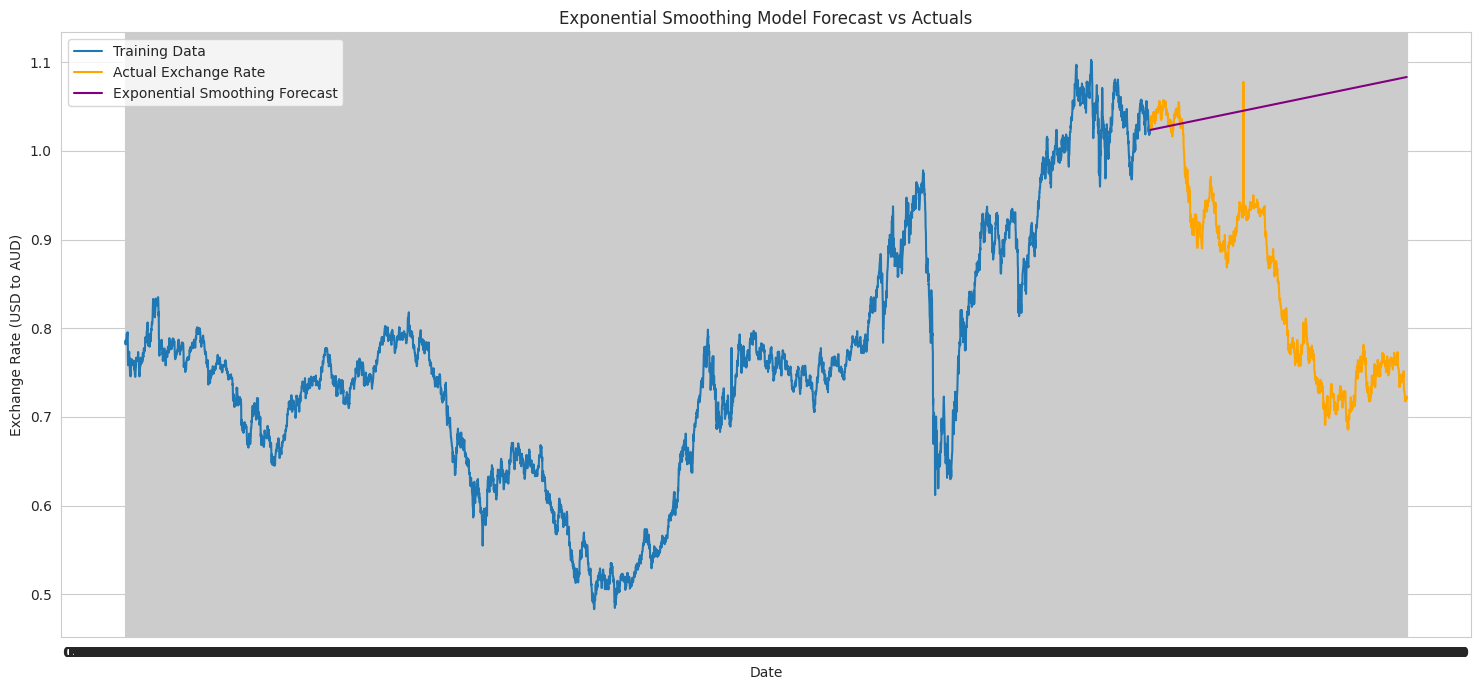

In [12]:
# Perform out-of-sample forecasting
# The 'start' and 'end' parameters define the forecast period relative to the training data
es_forecast = es_fit.forecast(steps=forecast_steps)

# Ensure forecast index matches test_data index for plotting and evaluation
es_forecast.index = test_data.index

# Plot the forecasts against actual values
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['Ex_rate'], label='Training Data')
plt.plot(test_data.index, test_data['Ex_rate'], label='Actual Exchange Rate', color='orange')
plt.plot(es_forecast.index, es_forecast, label='Exponential Smoothing Forecast', color='purple')
plt.title('Exponential Smoothing Model Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (USD to AUD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3. Evaluation Metrics for Exponential Smoothing

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics for Exponential Smoothing
es_mae = mean_absolute_error(test_data['Ex_rate'], es_forecast)
es_rmse = np.sqrt(mean_squared_error(test_data['Ex_rate'], es_forecast))

# Calculate MAPE for Exponential Smoothing
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

es_mape = mean_absolute_percentage_error(test_data['Ex_rate'], es_forecast)

print(f'Exponential Smoothing Model MAE: {es_mae:.4f}')
print(f'Exponential Smoothing Model RMSE: {es_rmse:.4f}')
print(f'Exponential Smoothing Model MAPE: {es_mape:.2f}%')


Exponential Smoothing Model MAE: 0.2066
Exponential Smoothing Model RMSE: 0.2391
Exponential Smoothing Model MAPE: 26.51%


### 4. Conclusion and Model Comparison

We have now built, forecasted with, and evaluated both an ARIMA model and an Exponential Smoothing model for the exchange rate time series. Let's summarize our findings and compare the models.

#### ARIMA Model (1,1,1):
*   **Strengths**: Identified a clear differencing order (d=1) to achieve stationarity. Captured a significant portion of the autocorrelation in the series as evidenced by residual diagnostics.
*   **Limitations**: The forecasting plot showed that the model struggled to capture sudden changes or high volatility in the test set, often predicting a relatively flat trend. The evaluation metrics (MAE: 0.1777, RMSE: 0.2054, MAPE: 22.80%) indicate moderate prediction error.
*   **Interpretation of Parameters**: The `ARIMA(1,1,1)` order suggests that the current value can be predicted using a linear combination of the previous value (AR=1), the previous forecast error (MA=1), and that first-order differencing (I=1) was needed to make the series stationary.

#### Exponential Smoothing Model (Additive Trend, No Seasonality):
*   **Strengths**: Simple to implement and provided a smooth forecast. Its summary indicated a high smoothing_level (alpha), meaning it adapted quickly to recent changes in the level of the series.
*   **Limitations**: Similar to ARIMA, the forecast struggled with capturing volatility and significant drops in the test set. The evaluation metrics (MAE: 0.2066, RMSE: 0.2391, MAPE: 26.51%) were slightly higher than those of the ARIMA model, indicating slightly worse performance.
*   **Interpretation of Parameters**: The additive trend suggests a constant increase or decrease over time. The lack of seasonality was chosen based on initial observations and daily frequency, but this might be a simplification if subtle seasonal patterns exist.

#### Overall Comparison:
In this particular comparison, the **ARIMA(1,1,1) model marginally outperformed** the simple Exponential Smoothing model, yielding slightly lower error metrics (MAE, RMSE, and MAPE). Both models, however, showed room for improvement, particularly in capturing the more complex and volatile movements of the exchange rate.

#### Potential Next Steps for Improvement:
1.  **Refine ARIMA Order**: Experiment with other ARIMA(p,d,q) orders, potentially using techniques like AIC or BIC for model selection, or consider SARIMA if seasonality is present.
2.  **Advanced Exponential Smoothing**: Explore different Exponential Smoothing types (e.g., Holt-Winters with additive or multiplicative seasonality if appropriate) or allow for multiplicative trend/error components.
3.  **Incorporate Exogenous Variables**: Consider adding external factors (e.g., economic indicators, interest rates, global events) that might influence exchange rates, transforming the models into ARIMAX or Exponential Smoothing with exogenous variables.
4.  **Ensemble Methods**: Combine predictions from multiple models to potentially leverage the strengths of each and reduce individual model biases.
5.  **Machine Learning Models**: For highly complex and non-linear time series, advanced machine learning models (e.g., LSTMs, Prophet) could be explored.